The objective is not “filtering” but detecting and repairing dropouts in a principled, reproducible way.

You are not “filtering noisy data.” You are:
- Detecting and correcting telemetry dropouts using structural rules based on system scale and temporal continuity.

This is defensible because:
- outages cannot physically drop to zero and recover in one hour
- customer base does not change abruptly
- behaviour is consistent across events

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet(r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_model_df.parquet")

# Core formatting
df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df = df.sort_values(["event_id", "CountyFIPS", "datetime"])

# Sanity checks
print(df.shape)
print(df.dtypes)

(17510, 22)
event_id                    string
storm                       string
geoid                       string
county                      string
datetime            datetime64[ns]
event_start         datetime64[ns]
duration_hours               int64
gust_mps                   float64
wind_speed_mps             float64
precip_mm                  float64
pressure_hpa               float64
temp_c                     float64
CountyFIPS                     str
outageFraction             float64
customersTracked           float64
persistence_1h             float64
error                      float64
abs_error                  float64
sq_error                   float64
persistence_24h            float64
persistence_48h            float64
persistence_72h            float64
dtype: object


In [2]:
def check_hourly_continuity(group):
    dt = group["datetime"].sort_values()
    diffs = dt.diff().dropna()
    return (diffs != pd.Timedelta(hours=1)).sum()

continuity = (
    df.groupby(["event_id", "CountyFIPS"])
      .apply(check_hourly_continuity)
      .reset_index(name="n_gaps")
)

print(continuity["n_gaps"].describe())

count    99.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: n_gaps, dtype: float64


In [3]:
def compute_tracking_stats(group):
    s = group["customersTracked"]

    return pd.Series({
        "min": s.min(),
        "max": s.max(),
        "frac_zero": (s == 0).mean(),
        "frac_small": (s < 0.1 * s.max()).mean(),
        "n_large_drops": ((s / s.shift(1)) < 0.2).sum()
    })

tracking_stats = (
    df.groupby(["event_id", "CountyFIPS"])
      .apply(compute_tracking_stats)
      .reset_index()
)

tracking_stats.describe()

,min,max,frac_zero,frac_small,n_large_drops
count,99.000000,9.900000e+01,99.000000,99.000000,99.000000
mean,54768.909091,1.303405e+05,0.016838,0.024786,1.505051
std,110698.091997,2.038188e+05,0.037908,0.052407,3.169928
min,-1.000000,2.029000e+03,0.000000,0.000000,0.000000
25%,0.000000,9.256000e+03,0.000000,0.000000,0.000000
50%,4675.000000,4.111300e+04,0.000000,0.000000,0.000000
75%,49679.500000,1.620505e+05,0.009970,0.024712,2.000000
max,631967.000000,1.124253e+06,0.166667,0.354545,21.000000


In [4]:
def flag_dropouts(group):
    s = group["customersTracked"]
    max_val = s.max()

    cond1 = s < 0.1 * max_val
    cond2 = (s / s.shift(1)) < 0.2
    cond3 = (s / s.shift(-1)) < 0.2

    return cond1 | cond2 | cond3

df["tracking_dropout_flag"] = (
    df.groupby(["event_id", "CountyFIPS"], group_keys=False)
      .apply(flag_dropouts)
)

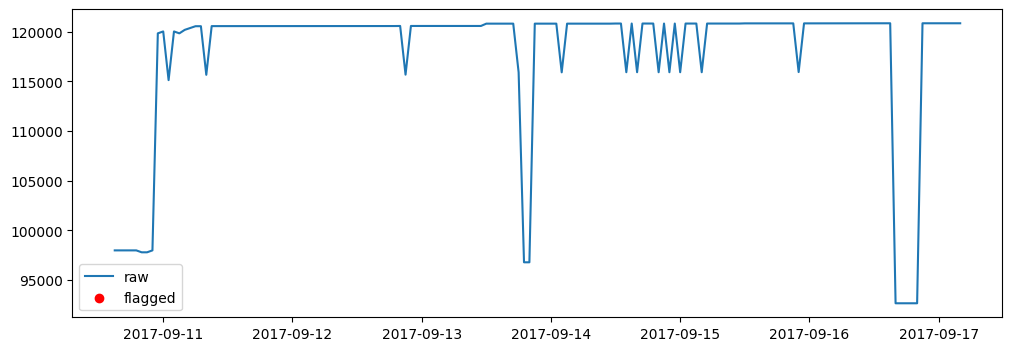

In [5]:
import matplotlib.pyplot as plt

sample = df[(df["event_id"] == df["event_id"].iloc[0]) & 
            (df["CountyFIPS"] == df["CountyFIPS"].iloc[0])]

plt.figure(figsize=(12,4))
plt.plot(sample["datetime"], sample["customersTracked"], label="raw")

mask = sample["tracking_dropout_flag"]
plt.scatter(sample.loc[mask, "datetime"],
            sample.loc[mask, "customersTracked"],
            color="red", label="flagged")

plt.legend()
plt.show()

In [6]:
df["customersTracked_clean"] = df["customersTracked"].where(
    ~df["tracking_dropout_flag"], np.nan
)

In [7]:
def interpolate_short_gaps(group, max_gap=6):
    s = group["customersTracked_clean"]

    return s.interpolate(
        method="linear",
        limit=max_gap,
        limit_direction="both"
    )

df["customersTracked_filled"] = (
    df.groupby(["event_id", "CountyFIPS"], group_keys=False)
      .apply(interpolate_short_gaps)
)

In [8]:
# reconstruct denominator proxy
df["max_customers"] = df.groupby(["event_id", "CountyFIPS"])["customersTracked_filled"].transform("max")

df["outageFraction_recalc"] = df["outageFraction"]  # placeholder

# optional consistency check
mask = df["customersTracked"].isna() | df["tracking_dropout_flag"]
print("Fraction of outageFraction affected:", mask.mean())

Fraction of outageFraction affected: 0.026727584237578525


KeyError: 'customersTracked_filled'

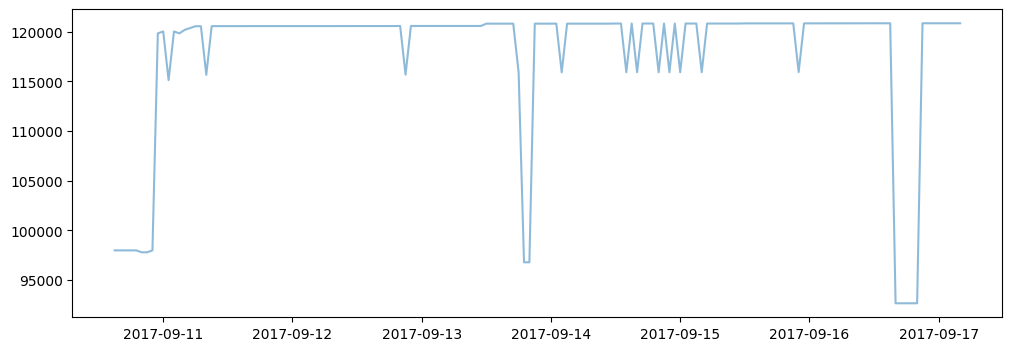

In [9]:
plt.figure(figsize=(12,4))
plt.plot(sample["datetime"], sample["customersTracked"], label="raw", alpha=0.5)
plt.plot(sample["datetime"], sample["customersTracked_filled"], label="cleaned")

plt.legend()
plt.show()

Selected group:
event_id: 12001_2017-09-11 03:00:00
CountyFIPS: 12001
n_rows: 158

Counts:
flag_zero_like    0
flag_drop_prev    0
flag_drop_next    0
flag_any          0
dtype: int64

Flagged rows:
Empty DataFrame
Columns: [datetime, customersTracked, prev, next, frac_of_max, ratio_prev, ratio_next, flag_any]
Index: []


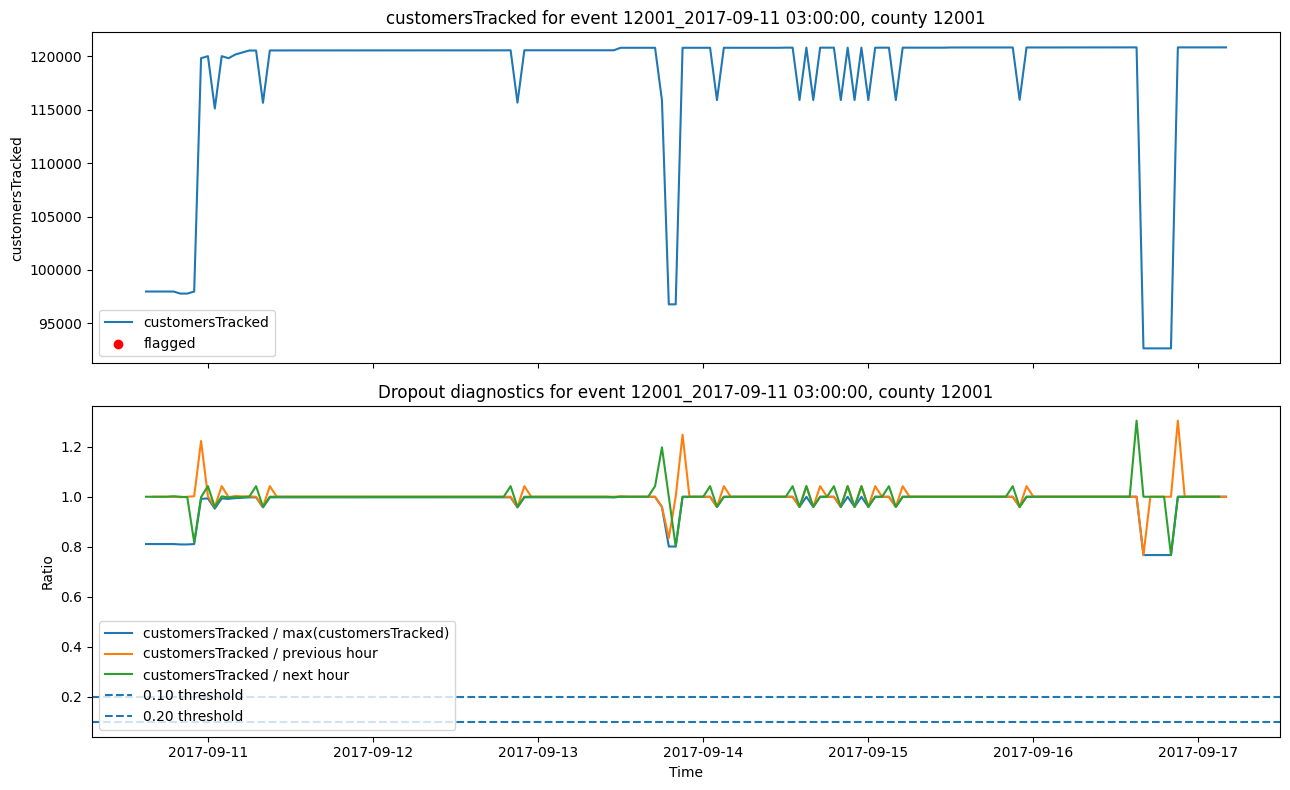

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pick one example group explicitly
event_id = df["event_id"].iloc[0]
county_fips = df["CountyFIPS"].iloc[0]

g = df[(df["event_id"] == event_id) & (df["CountyFIPS"] == county_fips)].copy()
g = g.sort_values("datetime").reset_index(drop=True)

print("Selected group:")
print("event_id:", event_id)
print("CountyFIPS:", county_fips)
print("n_rows:", len(g))
print()

s = g["customersTracked"]
mx = s.max()

g["prev"] = s.shift(1)
g["next"] = s.shift(-1)
g["ratio_prev"] = s / g["prev"]
g["ratio_next"] = s / g["next"]
g["frac_of_max"] = s / mx

# Current candidate flag logic, but shown explicitly
g["flag_zero_like"] = g["frac_of_max"] < 0.10
g["flag_drop_prev"] = g["ratio_prev"] < 0.20
g["flag_drop_next"] = g["ratio_next"] < 0.20
g["flag_any"] = g["flag_zero_like"] | g["flag_drop_prev"] | g["flag_drop_next"]

print("Counts:")
print(g[["flag_zero_like", "flag_drop_prev", "flag_drop_next", "flag_any"]].sum())
print()

print("Flagged rows:")
cols_to_show = ["datetime", "customersTracked", "prev", "next", "frac_of_max", "ratio_prev", "ratio_next", "flag_any"]
print(g.loc[g["flag_any"], cols_to_show].to_string(index=False))

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Plot 1: raw series with flagged points
ax[0].plot(g["datetime"], g["customersTracked"], label="customersTracked")
ax[0].scatter(
    g.loc[g["flag_any"], "datetime"],
    g.loc[g["flag_any"], "customersTracked"],
    color="red",
    label="flagged"
)
ax[0].set_title(f"customersTracked for event {event_id}, county {county_fips}")
ax[0].set_ylabel("customersTracked")
ax[0].legend()

# Plot 2: diagnostic ratios
ax[1].plot(g["datetime"], g["frac_of_max"], label="customersTracked / max(customersTracked)")
ax[1].plot(g["datetime"], g["ratio_prev"], label="customersTracked / previous hour")
ax[1].plot(g["datetime"], g["ratio_next"], label="customersTracked / next hour")
ax[1].axhline(0.10, linestyle="--", label="0.10 threshold")
ax[1].axhline(0.20, linestyle="--", label="0.20 threshold")
ax[1].set_title(f"Dropout diagnostics for event {event_id}, county {county_fips}")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Ratio")
ax[1].legend()

plt.tight_layout()
plt.show()

Top 10 groups by smallest previous-hour ratio
                 event_id CountyFIPS  n_rows  min_customersTracked  max_customersTracked  frac_zero  frac_below_10pct_max  min_ratio_prev  min_ratio_next  n_exact_zero
12007_2017-09-11 05:00:00      12007   189.0                   0.0                9843.0   0.042328              0.042328             0.0        0.000000           8.0
12005_2018-10-10 17:00:00      12005   528.0                   0.0              123951.0   0.009470              0.009470             0.0        0.121917           5.0
12013_2017-09-09 21:00:00      12013    78.0                   0.0                2029.0   0.166667              0.192308             0.0        0.000000          13.0
12011_2017-09-10 06:00:00      12011   202.0                   0.0              939339.0   0.163366              0.163366             0.0        0.000000          33.0
12013_2018-10-10 18:00:00      12013   535.0                   0.0                8695.0   0.024299              0

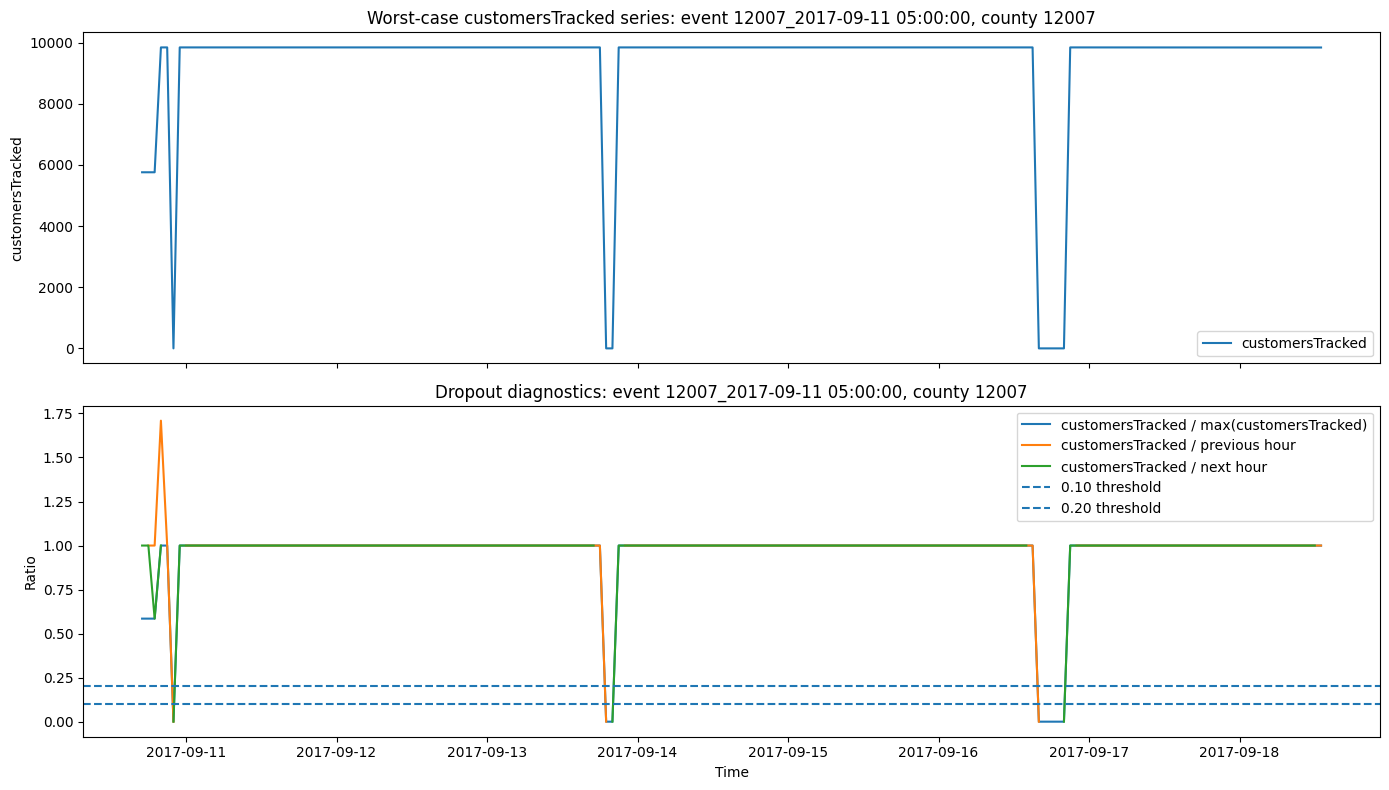

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Work on a sorted copy
d = df.sort_values(["event_id", "CountyFIPS", "datetime"]).copy()

def group_dropout_summary(g):
    s = g["customersTracked"].astype(float)
    prev = s.shift(1)
    nxt = s.shift(-1)

    ratio_prev = s / prev
    ratio_next = s / nxt

    return pd.Series({
        "n_rows": len(g),
        "min_customersTracked": s.min(),
        "max_customersTracked": s.max(),
        "frac_zero": (s == 0).mean(),
        "frac_below_10pct_max": (s < 0.10 * s.max()).mean(),
        "min_ratio_prev": ratio_prev.replace([np.inf, -np.inf], np.nan).min(),
        "min_ratio_next": ratio_next.replace([np.inf, -np.inf], np.nan).min(),
        "n_exact_zero": (s == 0).sum(),
    })

summary = (
    d.groupby(["event_id", "CountyFIPS"])
     .apply(group_dropout_summary)
     .reset_index()
)

print("Top 10 groups by smallest previous-hour ratio")
print(summary.sort_values("min_ratio_prev").head(10).to_string(index=False))
print("\nTop 10 groups by highest zero fraction")
print(summary.sort_values("frac_zero", ascending=False).head(10).to_string(index=False))

# Pick one extreme example to inspect
worst = summary.sort_values("min_ratio_prev").iloc[0]
event_id = worst["event_id"]
county_fips = worst["CountyFIPS"]

g = d[(d["event_id"] == event_id) & (d["CountyFIPS"] == county_fips)].copy()
g = g.sort_values("datetime").reset_index(drop=True)

s = g["customersTracked"].astype(float)
g["prev"] = s.shift(1)
g["next"] = s.shift(-1)
g["ratio_prev"] = s / g["prev"]
g["ratio_next"] = s / g["next"]
g["frac_of_max"] = s / s.max()

print("\nSelected worst group:")
print("event_id:", event_id)
print("CountyFIPS:", county_fips)
print(g[["datetime", "customersTracked", "prev", "next", "frac_of_max", "ratio_prev", "ratio_next"]].head(20).to_string(index=False))

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(g["datetime"], g["customersTracked"], label="customersTracked")
ax[0].set_title(f"Worst-case customersTracked series: event {event_id}, county {county_fips}")
ax[0].set_ylabel("customersTracked")
ax[0].legend()

ax[1].plot(g["datetime"], g["frac_of_max"], label="customersTracked / max(customersTracked)")
ax[1].plot(g["datetime"], g["ratio_prev"], label="customersTracked / previous hour")
ax[1].plot(g["datetime"], g["ratio_next"], label="customersTracked / next hour")
ax[1].axhline(0.10, linestyle="--", label="0.10 threshold")
ax[1].axhline(0.20, linestyle="--", label="0.20 threshold")
ax[1].set_title(f"Dropout diagnostics: event {event_id}, county {county_fips}")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Ratio")
ax[1].legend()

plt.tight_layout()
plt.show()

This output clarifies the structure cleanly.

What you are seeing is not “noisy variation”; it is a very specific failure mode:

customersTracked is piecewise constant at a stable level
Occasionally it drops to exactly 0 for 1–2 hours
Then immediately returns to the same level

That is a textbook telemetry dropout. There is no ambiguity here.

So the rule should be simple and structural, not threshold-heavy:

A value is invalid if it is (near) zero while both neighbours are large.

Do not rely on ratios alone; the inf/0 behaviour you saw makes that brittle.

In [12]:
g = g.copy()

s = g["customersTracked"]

# Define "low relative to system size"
threshold = 0.05 * s.max()

g["is_low"] = s <= threshold

# Neighbour context
g["prev"] = s.shift(1)
g["next"] = s.shift(-1)

g["prev_high"] = g["prev"] > threshold
g["next_high"] = g["next"] > threshold

# Core dropout condition
g["dropout_flag"] = g["is_low"] & g["prev_high"] & g["next_high"]

print("Number of flagged points:", g["dropout_flag"].sum())
print()

print(g.loc[g["dropout_flag"],
            ["datetime", "customersTracked", "prev", "next"]].to_string(index=False))

Number of flagged points: 1

           datetime  customersTracked   prev   next
2017-09-10 22:00:00               0.0 9842.0 9842.0


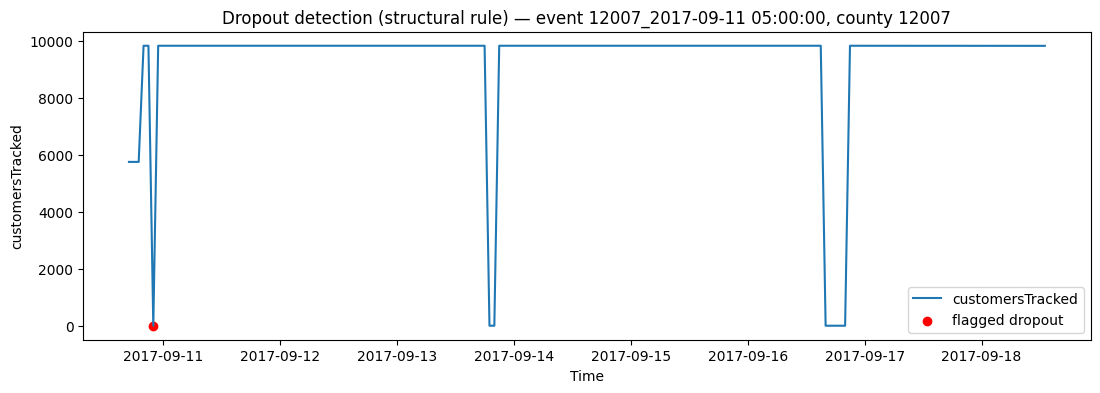

In [15]:
plt.figure(figsize=(13,4))

plt.plot(g["datetime"], g["customersTracked"], label="customersTracked")

plt.scatter(
    g.loc[g["dropout_flag"], "datetime"],
    g.loc[g["dropout_flag"], "customersTracked"],
    color="red",
    label="flagged dropout"
)

plt.title(f"Dropout detection (structural rule) — event {event_id}, county {county_fips}")
plt.xlabel("Time")
plt.ylabel("customersTracked")
plt.legend()

plt.show()

In [14]:
# Identify consecutive low runs
g["low_run_id"] = (g["is_low"] != g["is_low"].shift()).cumsum()

run_lengths = g.groupby("low_run_id")["is_low"].transform("sum")

# Flag short low runs surrounded by high values
g["dropout_flag_v2"] = (
    g["is_low"]
    & (run_lengths <= 3)   # allow up to 3-hour dropouts
)

print("Flagged (v2):", g["dropout_flag_v2"].sum())

Flagged (v2): 3


1. Use run-based detection as the primary definition

The correct abstraction is:

A dropout is a short contiguous period where customersTracked collapses relative to its event-scale.

So you should keep only this logic going forward:

In [16]:
g = g.copy()
s = g["customersTracked"]

threshold = 0.05 * s.max()

g["is_low"] = s <= threshold

# Identify contiguous runs
g["run_id"] = (g["is_low"] != g["is_low"].shift()).cumsum()
g["run_length"] = g.groupby("run_id")["is_low"].transform("sum")

# Final dropout flag
g["dropout_flag"] = g["is_low"] & (g["run_length"] <= 3)

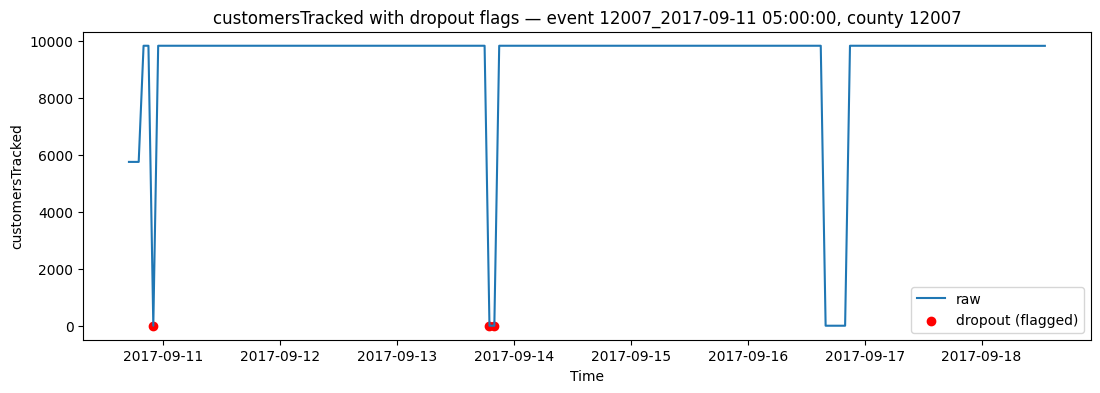

In [17]:
plt.figure(figsize=(13,4))

plt.plot(g["datetime"], g["customersTracked"], label="raw")

plt.scatter(
    g.loc[g["dropout_flag"], "datetime"],
    g.loc[g["dropout_flag"], "customersTracked"],
    color="red",
    label="dropout (flagged)"
)

plt.title(f"customersTracked with dropout flags — event {event_id}, county {county_fips}")
plt.xlabel("Time")
plt.ylabel("customersTracked")
plt.legend()

plt.show()

Yes. The 3-hour cap is too rigid. The next step is to separate two decisions:

What is a dropout?
How far are we willing to interpolate across it?

Those are not the same thing.

For customersTracked, the better definition is:

A dropout is any contiguous low-valued run that is bracketed by normal values on both sides.

That catches the longer internal outage in your plot without hardcoding a maximum length.

Use this next, one cell at a time.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = g.copy().sort_values("datetime").reset_index(drop=True)

s = g["customersTracked"].astype(float)
thr = 0.05 * s.max()

g["is_low"] = s <= thr
g["run_id"] = (g["is_low"] != g["is_low"].shift()).cumsum()
g["run_len"] = g.groupby("run_id")["is_low"].transform("sum")

# Identify whether a low run is bracketed by high values
run_info = (
    g.groupby("run_id")
     .agg(
         is_low=("is_low", "first"),
         start=("datetime", "first"),
         end=("datetime", "last"),
         min_ct=("customersTracked", "min"),
         max_ct=("customersTracked", "max"),
         n=("customersTracked", "size"),
     )
     .reset_index()
)

# Previous and next run values
run_info["prev_is_high"] = run_info["is_low"].shift(1).fillna(False) == False
run_info["next_is_high"] = run_info["is_low"].shift(-1).fillna(False) == False

# For low runs only: bracketed by high runs on both sides
run_info["dropout_run"] = (
    run_info["is_low"]
    & run_info["prev_is_high"]
    & run_info["next_is_high"]
)

print(run_info.loc[run_info["is_low"], ["run_id", "start", "end", "n", "min_ct", "max_ct", "dropout_run"]].to_string(index=False))

 run_id               start                 end  n  min_ct  max_ct  dropout_run
      2 2017-09-10 22:00:00 2017-09-10 22:00:00  1     0.0     0.0         True
      4 2017-09-13 19:00:00 2017-09-13 20:00:00  2     0.0     0.0         True
      6 2017-09-16 16:00:00 2017-09-16 20:00:00  5     0.0     0.0         True


In [19]:
dropout_run_ids = set(run_info.loc[run_info["dropout_run"], "run_id"])

g["dropout_flag"] = g["run_id"].isin(dropout_run_ids)

print("Flagged rows:", g["dropout_flag"].sum())

Flagged rows: 8


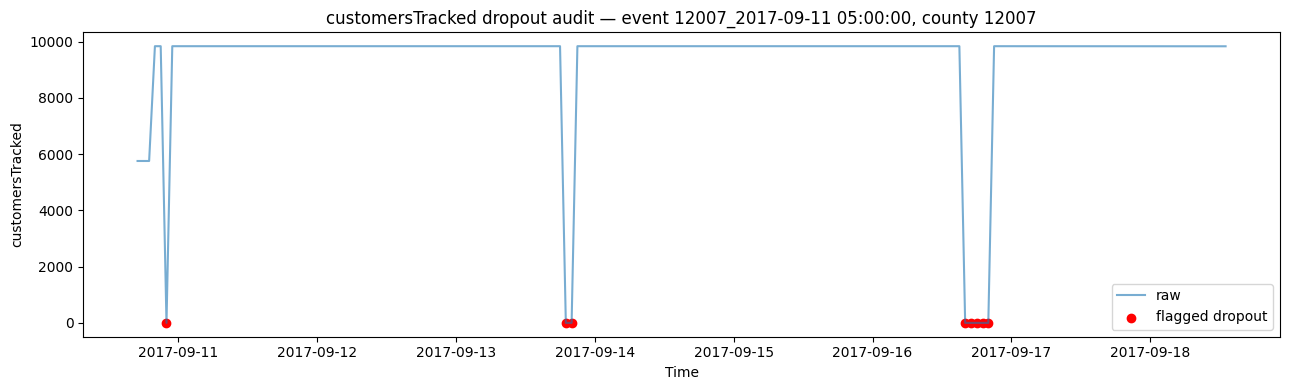

In [20]:
plt.figure(figsize=(13,4))
plt.plot(g["datetime"], g["customersTracked"], label="raw", alpha=0.6)
plt.scatter(
    g.loc[g["dropout_flag"], "datetime"],
    g.loc[g["dropout_flag"], "customersTracked"],
    color="red",
    label="flagged dropout"
)
plt.title(f"customersTracked dropout audit — event {event_id}, county {county_fips}")
plt.xlabel("Time")
plt.ylabel("customersTracked")
plt.legend()
plt.tight_layout()
plt.show()

For outageFraction, do not invent a different cleaning logic yet. First apply the same masked intervals from customersTracked and inspect whether the outage fraction is corrupted in exactly those windows. The simplest conservative version is:

In [21]:
g["customersTracked_clean"] = g["customersTracked"].where(~g["dropout_flag"], np.nan)
g["customersTracked_filled"] = g["customersTracked_clean"].interpolate(
    method="linear",
    limit_direction="both"
)
g["was_interpolated_ct"] = g["customersTracked_clean"].isna() & g["customersTracked_filled"].notna()

g["outageFraction_clean"] = g["outageFraction"].where(~g["dropout_flag"], np.nan)
g["outageFraction_filled"] = g["outageFraction_clean"].interpolate(
    method="linear",
    limit_direction="both"
)
g["was_interpolated_of"] = g["outageFraction_clean"].isna() & g["outageFraction_filled"].notna()

is_high should not mean “back to the event maximum.” That is too strict.

What it should mean is “back to a robust normal operating level for that event/county.” In other words, compare a low run to the local context, not to the absolute peak.

A better definition is:

low = values near zero relative to the event baseline
high = values that are back to a typical stable level for that same series (**rn 70%?**)

So the next step is to replace the crude is_high idea with a local-baseline rule. The simplest version is:

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = g.copy().sort_values("datetime").reset_index(drop=True)

s = g["customersTracked"].astype(float)

# Robust event baseline: stable central level, not the max
baseline = s[s > 0].median()
if pd.isna(baseline):
    baseline = s.max()

low_threshold = 0.05 * baseline
high_threshold = 0.70 * baseline   # "back to normal" does NOT mean back to max

g["is_low"] = s <= low_threshold
g["is_high"] = s >= high_threshold

What I would do from here is:

Lock down this one rule on customersTracked.
Apply the same logic to outageFraction, but treat it more cautiously because it is the target variable and may contain legitimate recovery structure.
Keep a full audit trail in the dataframe:
raw
baseline
low_threshold
high_threshold
is_low
dropout_flag
clean
filled
was_interpolated

In [30]:
print("Input df columns:")
print(list(df.columns))
print()
print("Input df index names:")
print(df.index.names)
print()
print("Has event_id in df:", "event_id" in df.columns)
print("Has CountyFIPS in df:", "CountyFIPS" in df.columns)
print()

LOW_FRAC = 0.05
HIGH_FRAC = 0.70
MAX_INTERP_GAP = 6

def clean_customers_tracked(group, low_frac=LOW_FRAC, high_frac=HIGH_FRAC, max_interp_gap=MAX_INTERP_GAP):
    event_id, county_fips = group.name

    g = group.sort_values("datetime").copy().reset_index(drop=True)
    g["event_id"] = event_id
    g["CountyFIPS"] = county_fips

    s = g["customersTracked"].astype(float)

    positive = s[s > 0]
    baseline = positive.median()
    if pd.isna(baseline):
        baseline = s.max()

    g["ct_baseline"] = baseline

    if pd.isna(baseline) or baseline <= 0:
        g["ct_low_threshold"] = np.nan
        g["ct_high_threshold"] = np.nan
        g["ct_is_low"] = False
        g["ct_run_id"] = 0
        g["ct_run_len"] = len(g)
        g["ct_dropout_run"] = False
        g["ct_dropout_flag"] = False
        g["customersTracked_clean"] = s
        g["customersTracked_filled"] = s
        g["customersTracked_was_interpolated"] = False
        g["ct_dropout_run_start"] = pd.NaT
        g["ct_dropout_run_end"] = pd.NaT
        return g

    low_thr = low_frac * baseline
    high_thr = high_frac * baseline

    is_low = s <= low_thr
    run_id = (is_low != is_low.shift()).cumsum()

    run_info = (
        pd.DataFrame({
            "run_id": run_id,
            "is_low": is_low,
            "customersTracked": s,
            "datetime": g["datetime"],
        })
        .groupby("run_id", as_index=True)
        .agg(
            is_low=("is_low", "first"),
            run_len=("is_low", "size"),
            run_median=("customersTracked", "median"),
            run_min=("customersTracked", "min"),
            start=("datetime", "first"),
            end=("datetime", "last"),
        )
    )

    run_info["prev_run_median"] = run_info["run_median"].shift(1)
    run_info["next_run_median"] = run_info["run_median"].shift(-1)

    run_info["dropout_run"] = (
        run_info["is_low"]
        & (run_info["prev_run_median"] >= high_thr)
        & (run_info["next_run_median"] >= high_thr)
    )

    dropout_run_ids = set(run_info.index[run_info["dropout_run"]])
    dropout_flag = run_id.isin(dropout_run_ids)

    ct_clean = s.mask(dropout_flag)
    ct_filled = ct_clean.copy()
    was_interp = pd.Series(False, index=g.index)

    run_id_np = run_id.to_numpy()
    for rid in dropout_run_ids:
        pos = np.flatnonzero(run_id_np == rid)
        if len(pos) == 0 or len(pos) > max_interp_gap:
            continue

        left = pos[0] - 1
        right = pos[-1] + 1
        if left < 0 or right >= len(g):
            continue

        left_val = ct_clean.iloc[left]
        right_val = ct_clean.iloc[right]
        if pd.isna(left_val) or pd.isna(right_val):
            continue

        interp_vals = np.linspace(left_val, right_val, len(pos) + 2)[1:-1]
        ct_filled.iloc[pos] = interp_vals
        was_interp.iloc[pos] = True

    g["ct_low_threshold"] = low_thr
    g["ct_high_threshold"] = high_thr
    g["ct_is_low"] = is_low
    g["ct_run_id"] = run_id.astype(int)
    g["ct_run_len"] = g["ct_run_id"].map(run_info["run_len"]).astype(int)
    g["ct_dropout_run"] = g["ct_run_id"].isin(dropout_run_ids)
    g["ct_dropout_flag"] = dropout_flag
    g["customersTracked_clean"] = ct_clean
    g["customersTracked_filled"] = ct_filled
    g["customersTracked_was_interpolated"] = was_interp
    g["ct_dropout_run_start"] = g["ct_run_id"].map(run_info["start"])
    g["ct_dropout_run_end"] = g["ct_run_id"].map(run_info["end"])

    return g

df_ct = (
    df.groupby(["event_id", "CountyFIPS"], group_keys=False)
      .apply(clean_customers_tracked)
      .reset_index(drop=True)
)

print("df_ct shape:", df_ct.shape)
print("columns:", list(df_ct.columns))
print()

print("Total flagged rows:", int(df_ct["ct_dropout_flag"].sum()))
print("Total interpolated rows:", int(df_ct["customersTracked_was_interpolated"].sum()))
print()

print("Flagged rows per event-county:")
print(
    df_ct.groupby(["event_id", "CountyFIPS"])["ct_dropout_flag"]
        .sum()
        .describe()
)

Input df columns:
['event_id', 'storm', 'geoid', 'county', 'datetime', 'event_start', 'duration_hours', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c', 'CountyFIPS', 'outageFraction', 'customersTracked', 'persistence_1h', 'error', 'abs_error', 'sq_error', 'persistence_24h', 'persistence_48h', 'persistence_72h', 'tracking_dropout_flag', 'customersTracked_clean', 'customersTracked_filled', 'max_customers', 'outageFraction_recalc']

Input df index names:
[None]

Has event_id in df: True
Has CountyFIPS in df: True

df_ct shape: (17510, 38)
columns: ['storm', 'geoid', 'county', 'datetime', 'event_start', 'duration_hours', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c', 'outageFraction', 'customersTracked', 'persistence_1h', 'error', 'abs_error', 'sq_error', 'persistence_24h', 'persistence_48h', 'persistence_72h', 'tracking_dropout_flag', 'customersTracked_clean', 'customersTracked_filled', 'max_customers', 'outageFraction_recalc', 'event_id', 'Count

Columns available:
['storm', 'geoid', 'county', 'datetime', 'event_start', 'duration_hours', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c', 'outageFraction', 'customersTracked', 'persistence_1h', 'error', 'abs_error', 'sq_error', 'persistence_24h', 'persistence_48h', 'persistence_72h', 'tracking_dropout_flag', 'customersTracked_clean', 'customersTracked_filled', 'max_customers', 'outageFraction_recalc', 'ct_baseline', 'ct_low_threshold', 'ct_high_threshold', 'ct_is_low', 'ct_run_id', 'ct_run_len', 'ct_dropout_run', 'ct_dropout_flag', 'customersTracked_was_interpolated', 'ct_dropout_run_start', 'ct_dropout_run_end', 'ct_dropout_flag_refined', 'event_id', 'CountyFIPS']

Using columns:
['event_id', 'CountyFIPS']


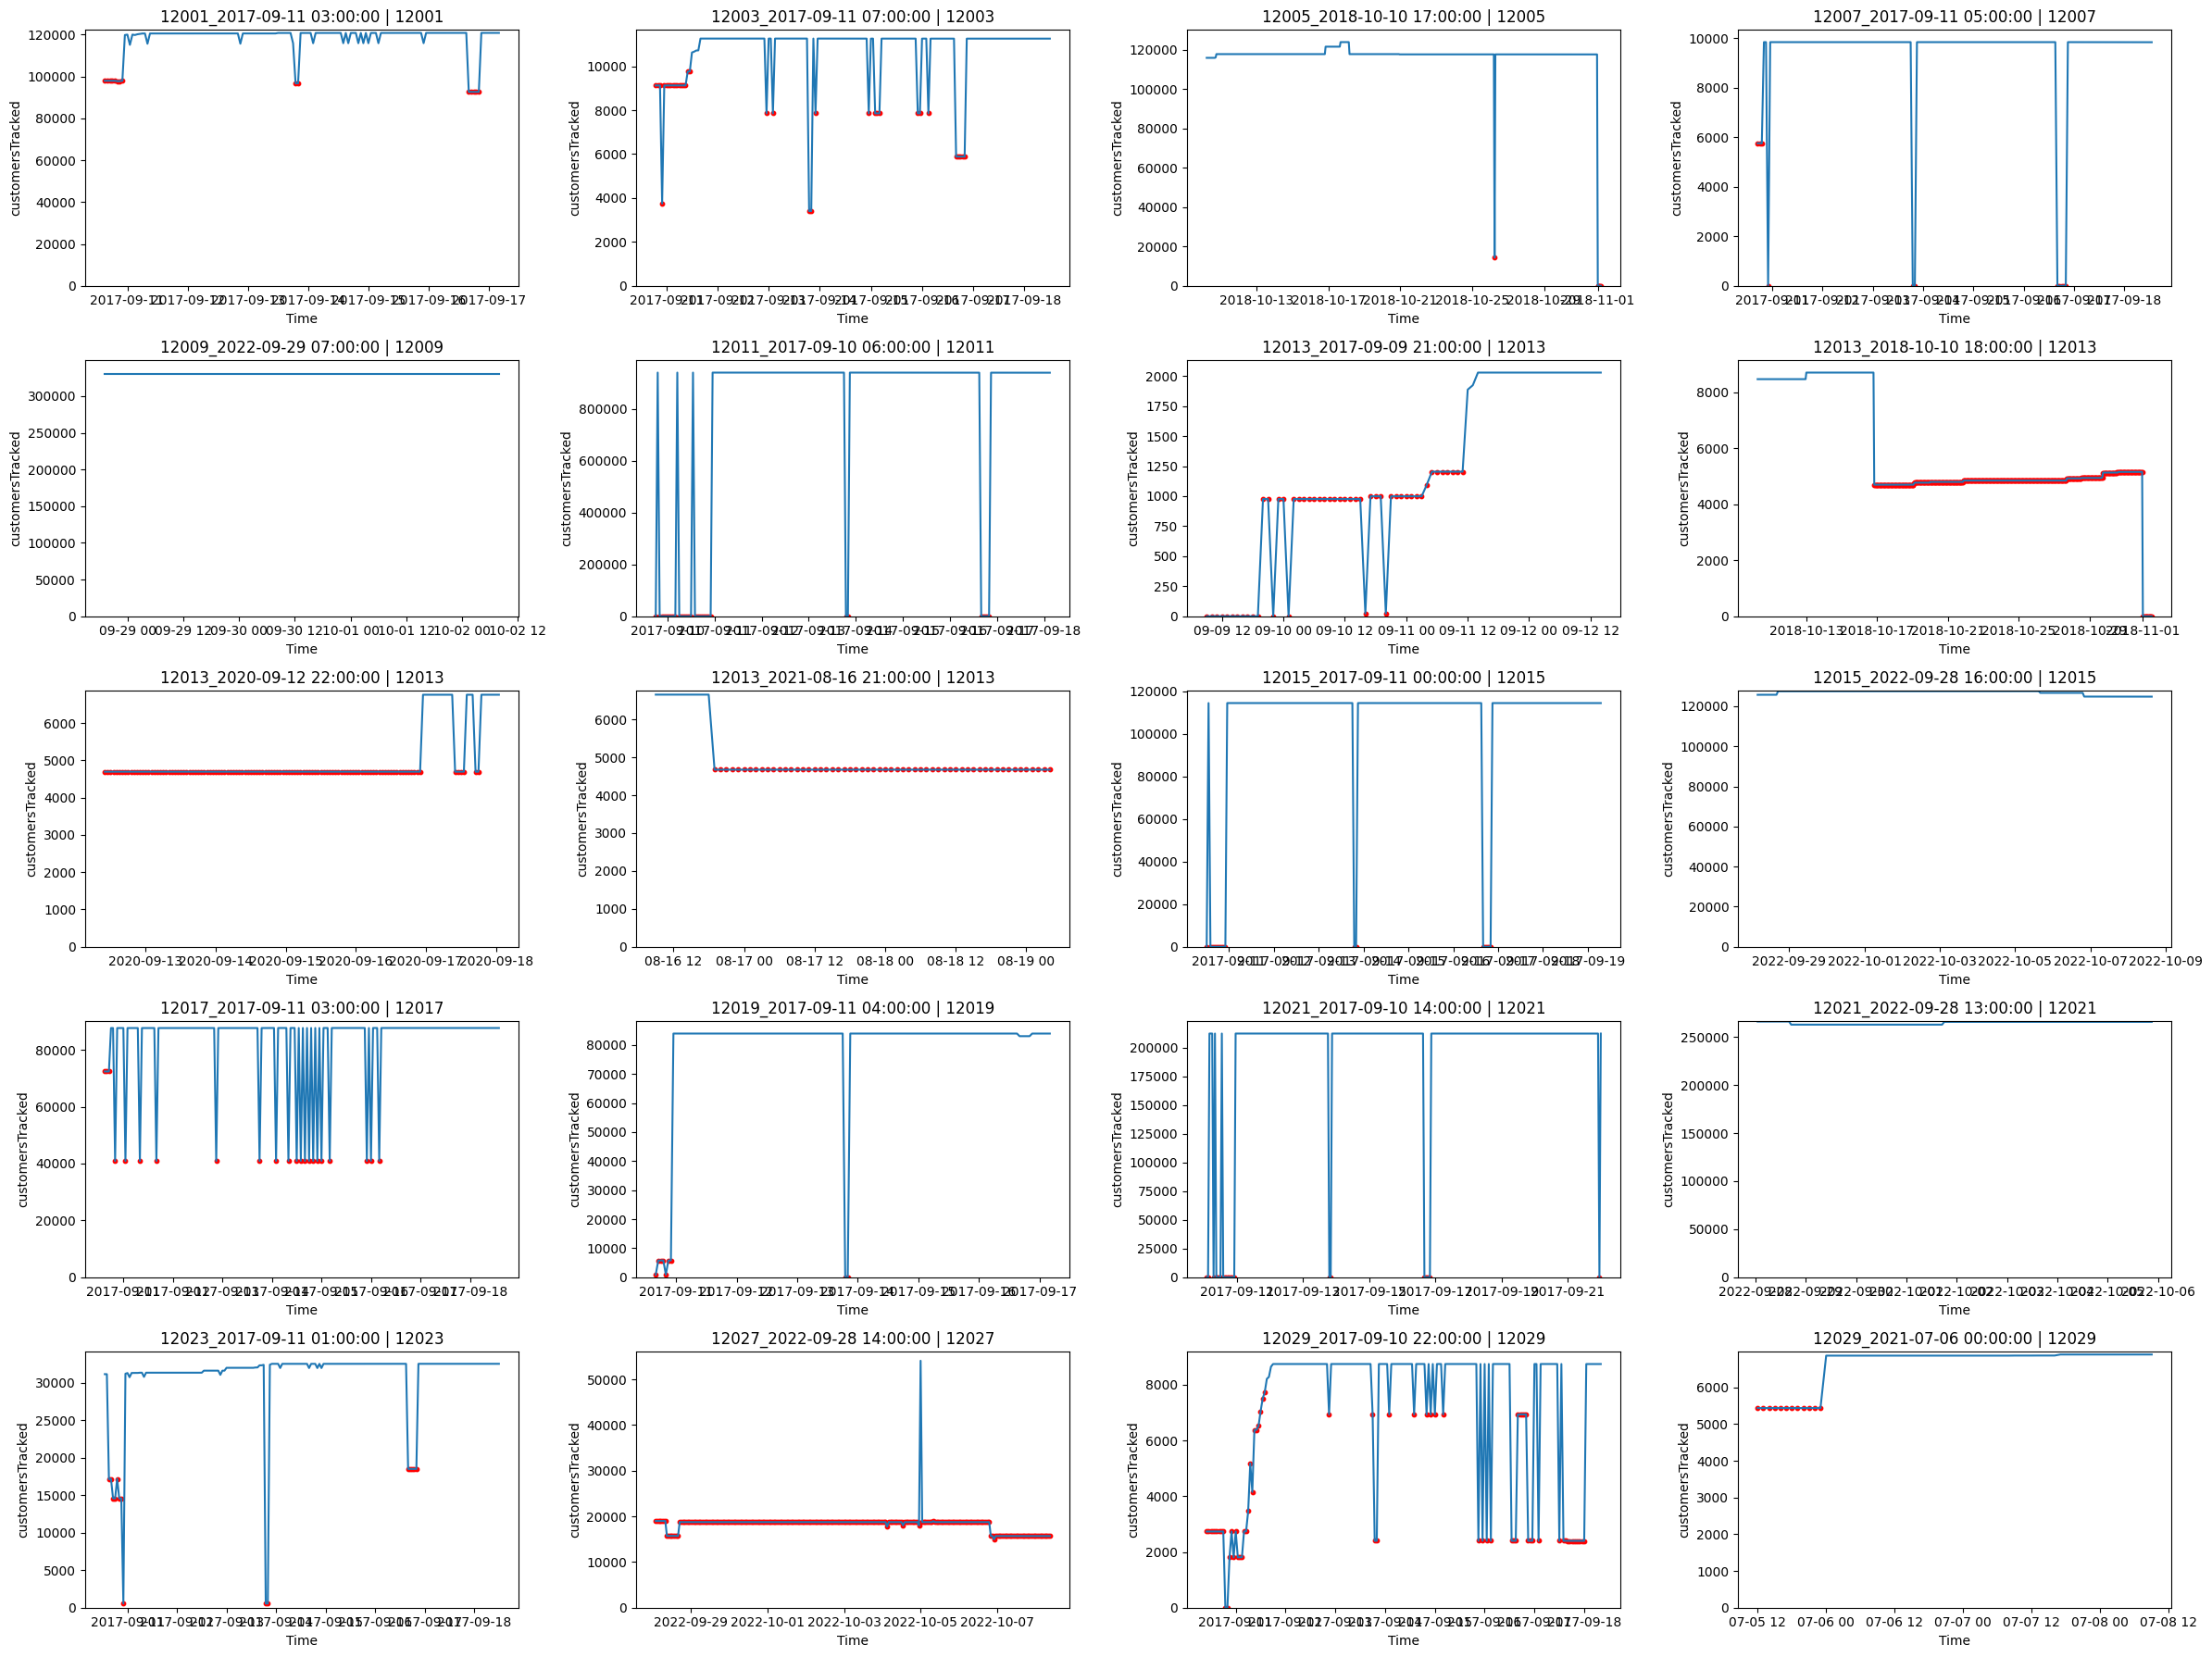

In [37]:
# Reconstruct event_id and CountyFIPS if missing, then plot

source_df = df_ct if "df_ct" in globals() else df

print("Columns available:")
print(list(source_df.columns))

# Reconstruct identifiers if missing
if "event_id" not in source_df.columns:
    if "event_start" in source_df.columns and "geoid" in source_df.columns:
        source_df["event_id"] = (
            source_df["geoid"].astype(str) + "_" +
            source_df["event_start"].astype(str)
        )
    else:
        raise KeyError("Cannot reconstruct event_id")

if "CountyFIPS" not in source_df.columns:
    if "geoid" in source_df.columns:
        source_df["CountyFIPS"] = source_df["geoid"].astype(str).str.zfill(5)
    else:
        raise KeyError("Cannot reconstruct CountyFIPS")

print("\nUsing columns:")
print(["event_id", "CountyFIPS"])

# Select 20 groups
groups = (
    source_df[["event_id", "CountyFIPS"]]
    .drop_duplicates()
    .head(20)
    .itertuples(index=False, name=None)
)

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax, (event_id, county_fips) in zip(axes, groups):
    g = source_df[
        (source_df["event_id"] == event_id) &
        (source_df["CountyFIPS"] == county_fips)
    ].sort_values("datetime")

    s = g["customersTracked"].astype(float)
    thr = 0.90 * s.max()
    flagged = s < thr

    ax.plot(g["datetime"], s)
    ax.scatter(g.loc[flagged, "datetime"], s[flagged], s=10, color='red')

    ax.set_title(f"{event_id} | {county_fips}")
    ax.set_xlabel("Time")
    ax.set_ylabel("customersTracked")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

wow. The customersTracked data is so incredibly bad.  because of instances like 12027, i think we’ll have to make the logic based on the 98th percentile (or something) and not pure max. thoughts? i guess at the end of the day, we're just using the upper range of customerstracked for a given event as a rough esetimate of the size of the grid, so perhaps we won't really do anything here since it's a bit of a fool's errand. perhaps we'll just note for the future that we'll be careful when utilizing customerstracked for any real data analsys
max(customersTracked) is not a reliable estimator of system size.
You should not try to “fully clean” customersTracked.
It is not worth the effort, and more importantly:
you risk introducing bias through reconstruction
the signal itself is not trustworthy at high frequency
Instead: Use a robust upper-envelope statistic as a proxy for system size.


Plotting chunk 3/5
Groups 41 to 60 of 99
Quantile line: q=0.95


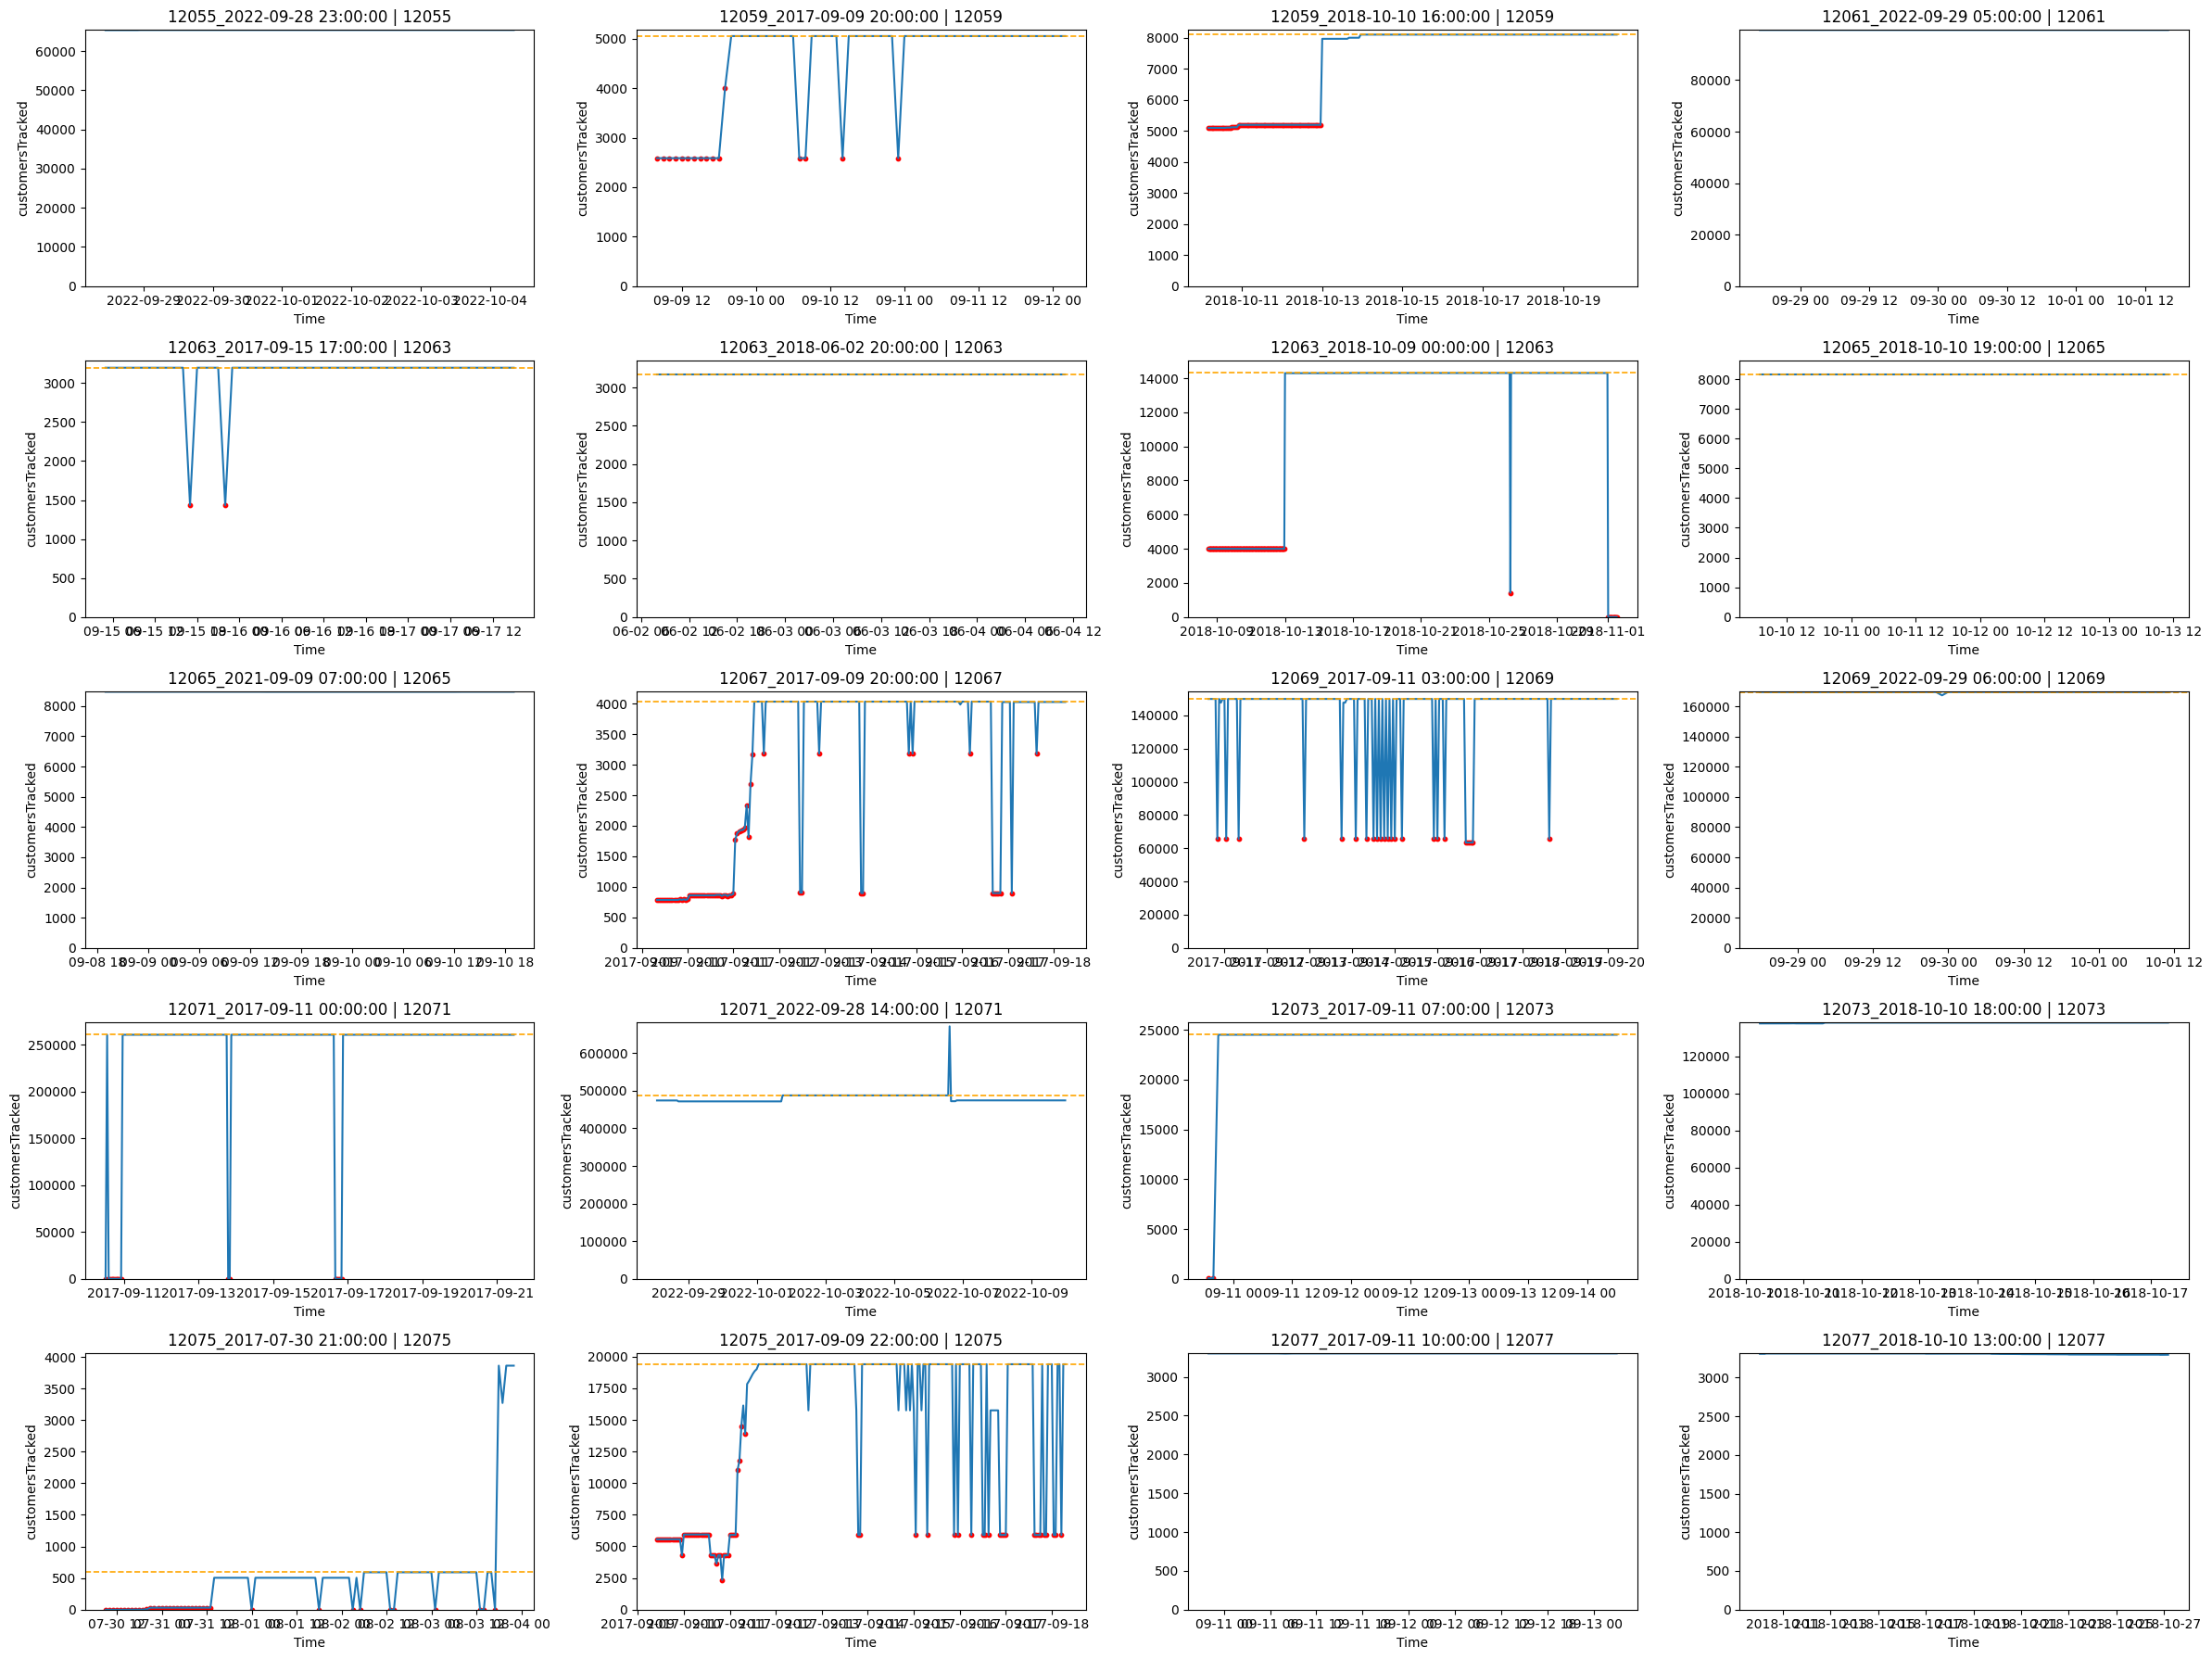

In [46]:
# Set these at the top
chunk = 3          # 1, 2, 3, 4, or 5
n_chunks = 5
plots_per_chunk = 20
q = 0.95           # dashed line quantile

source_df = df_ct if "df_ct" in globals() else df

# Reconstruct identifiers only if needed
if "event_id" not in source_df.columns:
    if {"geoid", "event_start"}.issubset(source_df.columns):
        source_df = source_df.copy()
        source_df["event_id"] = source_df["geoid"].astype(str) + "_" + source_df["event_start"].astype(str)
    else:
        raise KeyError("event_id is missing and cannot be reconstructed from geoid + event_start")

if "CountyFIPS" not in source_df.columns:
    if "geoid" in source_df.columns:
        source_df = source_df.copy()
        source_df["CountyFIPS"] = source_df["geoid"].astype(str).str.zfill(5)
    else:
        raise KeyError("CountyFIPS is missing and cannot be reconstructed from geoid")

required = {"event_id", "CountyFIPS", "datetime", "customersTracked"}
missing = required - set(source_df.columns)
if missing:
    raise KeyError(f"Missing required columns: {missing}")

groups_df = source_df[["event_id", "CountyFIPS"]].drop_duplicates().sort_values(["event_id", "CountyFIPS"]).reset_index(drop=True)
total_groups = len(groups_df)

start = (chunk - 1) * plots_per_chunk
end = min(start + plots_per_chunk, total_groups)

if chunk < 1 or chunk > n_chunks:
    raise ValueError(f"chunk must be between 1 and {n_chunks}")

if start >= total_groups:
    raise ValueError(f"Chunk {chunk} is out of range for {total_groups} total groups")

print(f"Plotting chunk {chunk}/{n_chunks}")
print(f"Groups {start + 1} to {end} of {total_groups}")
print(f"Quantile line: q={q}")

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups_df.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]

    g = source_df[
        (source_df["event_id"] == event_id) &
        (source_df["CountyFIPS"] == county_fips)
    ].sort_values("datetime").copy()

    s = g["customersTracked"].astype(float)
    thr = s.quantile(q)
    flagged = s < (0.8 * thr)

    ax.set_visible(True)
    ax.plot(g["datetime"], s, linewidth=1.5)
    ax.scatter(g.loc[flagged, "datetime"], s[flagged], s=10, color="red")
    ax.axhline(thr, linestyle="--", linewidth=1.2, color='orange')

    ax.set_title(f"{event_id} | {county_fips}")
    ax.set_xlabel("Time")
    ax.set_ylabel("customersTracked")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

county 12075 is weird; let's inspect it more closely
- chunk 3, bottom-left plot above

Parquet schema columns:
['OutageFraction', 'CustomersTracked', 'RecordDateTime', 'CountyFIPS']

Matched names:
dt_col: RecordDateTime
ct_col: CustomersTracked
of_col: OutageFraction
county_col: CountyFIPS

Arrow table schema:
RecordDateTime: timestamp[ns]
CountyFIPS: string
CustomersTracked: double
OutageFraction: double
-- schema metadata --
pandas: '{"index_columns": ["RecordDateTime", "CountyFIPS"], "column_inde' + 743

Pandas columns immediately after to_pandas():
['CustomersTracked', 'OutageFraction']
Pandas index name(s): ['RecordDateTime', 'CountyFIPS']
Shape: (1441, 2)

Head:
                                CustomersTracked  OutageFraction
RecordDateTime      CountyFIPS                                  
2017-06-30 21:00:00 12075                 3259.0        0.001227
2017-06-30 22:00:00 12075                 3259.0        0.000307
2017-06-30 23:00:00 12075                 3259.0        0.001227
2017-07-01 00:00:00 12075                 3259.0        0.040196
2017-07-01 01:00:00

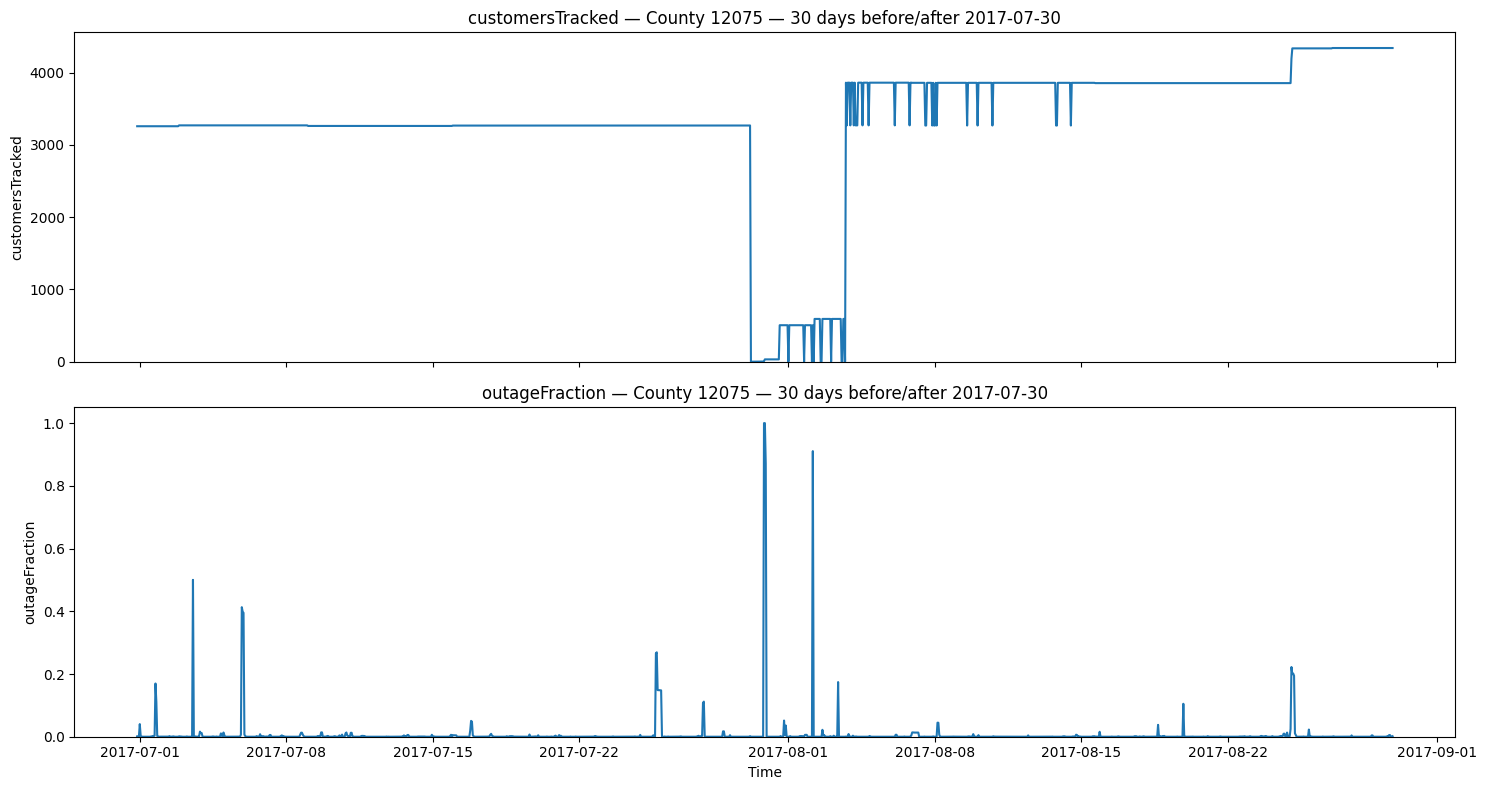

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
import pyarrow as pa

pq_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq"

event_id = "12075_2017-07-30 21:00:00"
county_fips = "12075"
event_start = pd.to_datetime(event_id.split("_", 1)[1])

start = event_start - pd.Timedelta(days=30)
end = event_start + pd.Timedelta(days=30)

dataset = ds.dataset(pq_path, format="parquet")
schema_names = list(dataset.schema.names)

print("Parquet schema columns:")
print(schema_names)

def pick_name(candidates):
    lower_map = {c.lower(): c for c in schema_names}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

dt_col = pick_name(["RecordDateTime", "datetime"])
ct_col = pick_name(["CustomersTracked", "customersTracked"])
of_col = pick_name(["OutageFraction", "outageFraction"])
county_col = pick_name(["CountyFIPS", "geoid"])

print("\nMatched names:")
print("dt_col:", dt_col)
print("ct_col:", ct_col)
print("of_col:", of_col)
print("county_col:", county_col)

scanner = dataset.scanner(
    columns=[dt_col, county_col, ct_col, of_col],
    filter=((ds.field(county_col) == county_fips) &
            (ds.field(dt_col) >= pa.scalar(start.to_pydatetime())) &
            (ds.field(dt_col) <= pa.scalar(end.to_pydatetime())))
)

table = scanner.to_table()
print("\nArrow table schema:")
print(table.schema)

df_raw = table.to_pandas()

print("\nPandas columns immediately after to_pandas():")
print(df_raw.columns.tolist())
print("Pandas index name(s):", df_raw.index.names)
print("Shape:", df_raw.shape)
print("\nHead:")
print(df_raw.head().to_string())

# If the datetime landed in the index, recover it
if "datetime" not in df_raw.columns:
    if dt_col in df_raw.index.names:
        df_raw = df_raw.reset_index()
    elif df_raw.index.name == dt_col:
        df_raw = df_raw.reset_index()

# Standardize names if they are present
rename_map = {}
if dt_col in df_raw.columns:
    rename_map[dt_col] = "datetime"
if ct_col in df_raw.columns:
    rename_map[ct_col] = "customersTracked"
if of_col in df_raw.columns:
    rename_map[of_col] = "outageFraction"
if county_col in df_raw.columns:
    rename_map[county_col] = "CountyFIPS"

df_raw = df_raw.rename(columns=rename_map)

print("\nColumns after rename:")
print(df_raw.columns.tolist())
print("Index names after rename:", df_raw.index.names)

if "datetime" not in df_raw.columns:
    raise KeyError("datetime still missing after inspection/repair.")

df_raw = df_raw.sort_values("datetime").reset_index(drop=True)

fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax[0].plot(df_raw["datetime"], df_raw["customersTracked"])
ax[0].set_title(f"customersTracked — County {county_fips} — 30 days before/after {event_start.date()}")
ax[0].set_ylabel("customersTracked")
ax[0].set_ylim(bottom=0)

ax[1].plot(df_raw["datetime"], df_raw["outageFraction"])
ax[1].set_title(f"outageFraction — County {county_fips} — 30 days before/after {event_start.date()}")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("outageFraction")
ax[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Maybe we should use population rather than customerstracked then?
Yes let’s do this. customersTracked is not just noisy; it’s non-stationary and regime-dependent. That makes it a poor standalone proxy for system size in a regression meant to generalise across storms.